In [1]:
import lightcurve
from lightcurve import generate_snia_lightcurve, generate_custom_model, fixed_param, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, make_visibility_row, determine_visibility

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import numpy as np
from matplotlib import pyplot as plt

from lightcurve import snia_lightcurve_params

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]

In [17]:
import skysurvey
new_snia = skysurvey.SNeIa().from_draw(1)
print(new_snia.data)
t0 = new_snia.data["t0"][0] #check why u need 0 again. because of index 0?
phase_start = new_snia.template.get().mintime()
phase_stop = min(new_snia.template.get().maxtime(), 200.0)
times = np.linspace(phase_start, phase_stop, 500) + t0
lc = new_snia.get_lightcurve(band = ["lsstr"], phase_range = (phase_start, phase_stop), times=times,index=0,zp=25,in_mag=True)

         z    x1      c           t0          ra        dec     magabs  \
0  0.14585  0.26 -0.064  56029.90625  256.374481  17.843931 -19.544266   

      magobs template  
0  19.726334    salt2  


In [19]:
lc.shape

(1, 500)

### Generate fixed parameters

{'redshift': {'func': <function fixed_param at 0x75c364a72fb0>, 'kwargs': {'size': 1, 'value': 0.01}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x75c364a72fb0>, 'kwargs': {'size': 1, 'value': -18.523}, 'as': 'magabs'}} <class 'dict'>


Skipping lsstz: outside model range.
Skipping lssty: outside model range.
valid bands are: ['lsstu', 'lsstg', 'lsstr', 'lssti']


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


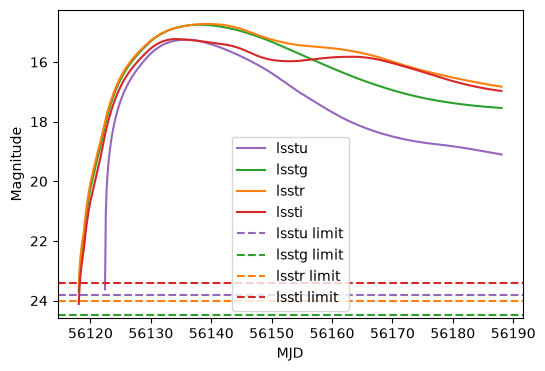

{'redshift': {'func': <function fixed_param at 0x75c364a72fb0>, 'kwargs': {'size': 1, 'value': 0.5}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x75c364a72fb0>, 'kwargs': {'size': 1, 'value': -18.523}, 'as': 'magabs'}} <class 'dict'>
valid bands are: ['lsstu', 'lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty']


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


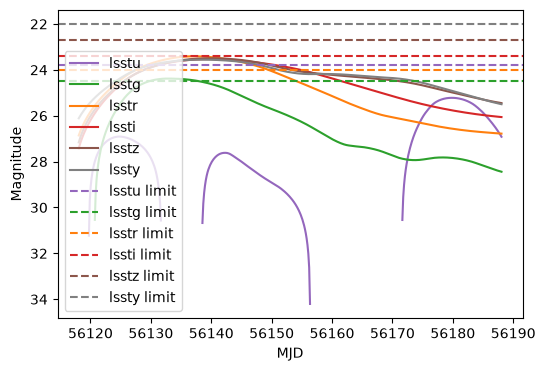

In [3]:
snia_models = []
data_models = []
for redshift in [0.01, 0.5]:
    #keep the other params fixed
    snia_dict = None #initiate with None
    snia_dict = generate_snia_dict(ra = None, dec = None, redshift=redshift, x1 = None, magabs = -18.523, c = None)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_model, model_data = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, plot_curve = True, return_values = True, return_models = True)
    snia_models.append(snia_model)
    data_models.append(model_data)

In [ ]:
# input data points at every cadence.
# include a survey which gives you data points within this lc based on the pos in the sky
# and whether the obs

In [10]:
len(data_models)
visibility = determine_visibility(data_models[1])
visibility

KeyError: 'lc'

In [11]:
data_models[0]['times']
data_models[0]['lc_by_band']

{'lsstu': array([        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan, 23.62432492, 20.98302588, 20.22798703, 19.75757278,
        19.41067838, 19.12817136, 18.88842494, 18.68032612, 18.49677305,
        18.33292645, 18.18532769, 18.05132693, 17.92700605, 17.81071452,
        17.7019215 , 17.60011058, 17.50479622, 17.41553113, 17.33190794,
        17.25274701, 17.17714807, 17.10501204, 17.03622865, 16.97068253,
        16.90825751, 16.84883951, 16.79218411, 16.73784659, 16.68558637,
        16.63519924, 16.58650706, 16.53935366, 16.49360145, 16.44916209,
        16.40603992, 16.36412527, 16.32330

In [8]:
data = data_models[0]
data

{'times': array([56118.05859375, 56118.19887431, 56118.33915487, 56118.47943543,
        56118.61971599, 56118.75999656, 56118.90027712, 56119.04055768,
        56119.18083824, 56119.3211188 , 56119.46139936, 56119.60167992,
        56119.74196048, 56119.88224104, 56120.02252161, 56120.16280217,
        56120.30308273, 56120.44336329, 56120.58364385, 56120.72392441,
        56120.86420497, 56121.00448553, 56121.14476609, 56121.28504666,
        56121.42532722, 56121.56560778, 56121.70588834, 56121.8461689 ,
        56121.98644946, 56122.12673002, 56122.26701058, 56122.40729114,
        56122.54757171, 56122.68785227, 56122.82813283, 56122.96841339,
        56123.10869395, 56123.24897451, 56123.38925507, 56123.52953563,
        56123.66981619, 56123.81009676, 56123.95037732, 56124.09065788,
        56124.23093844, 56124.371219  , 56124.51149956, 56124.65178012,
        56124.79206068, 56124.93234124, 56125.07262181, 56125.21290237,
        56125.35318293, 56125.49346349, 56125.63374405,

In [ ]:
import pandas as pd
rows = []
# model is the skysurvey.core.target.Target, data is the y data
for model, data in zip(snia_models, data_models):
    vis = determine_visibility(lightcurves_data = data, return_dict = True) #this makes a dict
    row = {**{k: model.data[k][0] for k in snia_lightcurve_params}, **vis}
    rows.append(row)

df = pd.DataFrame(
    rows,
    index=[f"{i}" for i in range(len(data_models))],
    columns=snia_lightcurve_params + bands
)

df.index.name = "Target"


KeyError: 'lc'

TypeError: only 0-dimensional arrays can be converted to Python scalars